# SIOC 251: Homework 3 
## Monte Carlo Radiative Transfer with Isotropic Scattering

**Sophie Wynn**



##  Part I
---
## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

rng = np.random.default_rng(seed=42)

mpl.rcParams.update({
    'font.size': 15,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'figure.dpi': 120,
})

Z_ATM     = 8500.0    
N_PHOTONS = 100_000   # default number of photons

print('Imports complete.')

Imports complete.


---
## HW1 Model

The pure-absorption model from HW1. Each photon either reaches the surface or is absorbed in the atmosphere — no scattering yet.

In [2]:
def run_monte_carlo_hw1(tau_star, sza_deg, n_photons=N_PHOTONS, rng=rng):
    """HW1 Monte Carlo: pure absorption, no scattering.

    Photons enter at the top, travel along the slant path, and either
    reach the surface or are absorbed.
    """
    mu = np.cos(np.deg2rad(sza_deg))

    zeta = rng.uniform(0.0, 1.0, size=n_photons)
    tau_sampled = -np.log(1.0 - zeta)   # inverse-CDF of exponential

    if mu <= 0.0:
        return {'transmittance': 0.0, 'n_surface': 0, 'n_absorbed': n_photons,
                'tau_star': tau_star, 'sza_deg': sza_deg, 'mu': mu}

    # A photon reaches the surface if its sampled optical depth exceeds
    # the slant-path optical depth through the full atmosphere: tau*/mu
    reaches_surface = tau_sampled >= (tau_star / mu)
    n_surface  = int(np.sum(reaches_surface))
    n_absorbed = n_photons - n_surface

    return {
        'transmittance': n_surface / n_photons,
        'n_surface':     n_surface,
        'n_absorbed':    n_absorbed,
        'tau_star':      tau_star,
        'sza_deg':       sza_deg,
        'mu':            mu,
    }

# quick sanity check against HW1 numbers
for tau, sza in [(0.1, 0), (1.0, 0), (1.0, 60), (3.0, 0)]:
    T = run_monte_carlo_hw1(tau, sza)['transmittance']
    print(f'tau*={tau:>4.1f}  SZA={sza:>3d}deg   T = {T:.4f}   (Beer: {np.exp(-tau/np.cos(np.deg2rad(sza))):.4f})')

tau*= 0.1  SZA=  0deg   T = 0.9055   (Beer: 0.9048)
tau*= 1.0  SZA=  0deg   T = 0.3659   (Beer: 0.3679)
tau*= 1.0  SZA= 60deg   T = 0.1344   (Beer: 0.1353)
tau*= 3.0  SZA=  0deg   T = 0.0497   (Beer: 0.0498)


---
## Part I.1: Model Construction

### Physics extensions over HW1

### Part I(a) 

In [3]:
# --- Functions for HW3 Part I: scattering model ---
def sample_path_length(rng):
    """Draw a path length in optical-depth units from the exponential CDF."""
    zeta = rng.uniform(0.0, 1.0)
    return -np.log(1.0 - zeta)

def run_monte_carlo_scatter_part1a(tau_star, sza_deg, omega, n_photons=N_PHOTONS, rng=rng):
    """HW3 Monte Carlo: scattering and absorption.

    Photons enter at the top, travel along the slant path, and either
    reach the surface or scattered or absorbed.
    """
    mu = np.cos(np.deg2rad(sza_deg))

    zeta = rng.uniform(0.0, 1.0, size=n_photons)
    tau_sampled = -np.log(1.0 - zeta)   # inverse-CDF of exponential

    if mu <= 0.0:
        return {'transmittance': 0.0, 'n_surface': 0, 'n_absorbed': n_photons,
                'tau_star': tau_star, 'sza_deg': sza_deg, 'mu': mu}

    # A photon reaches the surface if its sampled optical depth exceeds
    # the slant-path optical depth through the full atmosphere: tau*/mu
    # add fter each photon path length is calculated, the photon can either be absorbed or scattered
    

    reaches_surface = tau_sampled >= (tau_star / mu)   # the photon reaches the surface without interacting
    interacts       = ~reaches_surface                  # photon DOES interact
    zeta_int        = rng.uniform(0, 1, size=n_photons)
    scattered       = interacts & (zeta_int <  omega)   # of those that interact, the scatters
    absorbed        = interacts & (zeta_int >= omega)   # of those that interact, the absorbs



    n_surface   = int(np.sum(reaches_surface))
    n_scattered = int(np.sum(scattered))
    n_absorbed  = int(np.sum(absorbed))

    return {
        'transmittance': n_surface   / n_photons,
        'f_scattered':   n_scattered / n_photons,
        'f_absorbed':    n_absorbed  / n_photons,
        'n_surface':     n_surface,
        'n_scattered':   n_scattered,
        'n_absorbed':    n_absorbed,
        'tau_star': tau_star, 'sza_deg': sza_deg, 'omega': omega, 'mu': mu,
    }

In [4]:
omega = 0.7
out = run_monte_carlo_scatter_part1a(tau_star=2.0, sza_deg=0.0,
                                omega=omega, n_photons=100_000)

n_interact = out['n_scattered'] + out['n_absorbed']
ratio = out['n_scattered'] / n_interact
print(f"omega input   = {omega}")
print(f"scattered / interactions = {ratio:.4f}   (should ≈ {omega})")

omega input   = 0.7
scattered / interactions = 0.6994   (should ≈ 0.7)


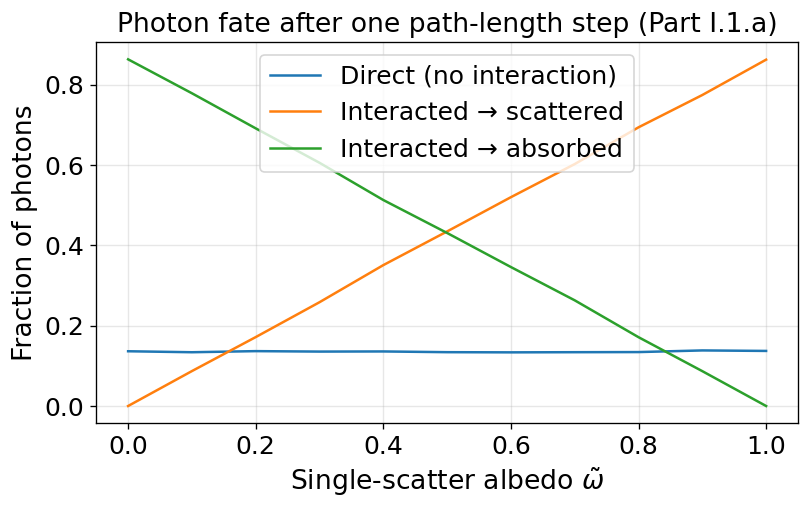

In [5]:
omegas = np.linspace(0, 1, 11)
f_direct   = []
f_scatter  = []
f_absorb   = []

for w in omegas:
    out = run_monte_carlo_scatter_part1a(tau_star=2.0, sza_deg=0.0,
                                    omega=w, n_photons=50_000)
    f_direct.append(out['transmittance'])
    f_scatter.append(out['f_scattered'])
    f_absorb.append(out['f_absorbed'])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(omegas, f_direct,   label='Direct (no interaction)')
ax.plot(omegas, f_scatter,  label='Interacted → scattered')
ax.plot(omegas, f_absorb,   label='Interacted → absorbed')
ax.set_xlabel(r'Single-scatter albedo $\tilde\omega$')
ax.set_ylabel('Fraction of photons')
ax.set_title(r'Photon fate after one path-length step (Part I.1.a)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Part I.1.b — Inverting the CDF for isotropic scattering

For isotropic scattering, $P(\cos\Theta) = 1$, so
$$C(\cos\Theta) = \tfrac{1}{2} \int_{-1}^{\cos\Theta} 1\,dx = \tfrac{1}{2}(\cos\Theta + 1).$$
Setting $C = \zeta \in U(0,1)$ and solving:
$$\boxed{\cos\Theta = 2\zeta - 1}.$$

 ### Part I.1c. Choose a scattering angle in the azimuthal direction, Φ, by drawing another random number from a uniform distribution between 0 and 2π.

In [6]:

def run_monte_carlo_scatter_part1c(tau_star, sza_deg, omega, n_photons=N_PHOTONS, rng=rng):
    """HW3 Monte Carlo: scattering and absorption.

    Photons enter at the top, travel along the slant path, and either
    reach the surface or scattered or absorbed.
    """
    mu = np.cos(np.deg2rad(sza_deg))

    zeta = rng.uniform(0.0, 1.0, size=n_photons)
    tau_sampled = -np.log(1.0 - zeta)   # inverse-CDF of exponential

    if mu <= 0.0:
        return {'transmittance': 0.0, 'n_surface': 0, 'n_absorbed': n_photons,
                'tau_star': tau_star, 'sza_deg': sza_deg, 'mu': mu}

    # A photon reaches the surface if its sampled optical depth exceeds
    # the slant-path optical depth through the full atmosphere: tau*/mu
    # add fter each photon path length is calculated, the photon can either be absorbed or scattered
    

    reaches_surface = tau_sampled >= (tau_star / mu)   # the photon reaches the surface without interacting
    interacts       = ~reaches_surface                  # photon DOES interact
    zeta_int        = rng.uniform(0, 1, size=n_photons)
    scattered       = interacts & (zeta_int <  omega)   # of those that interact, the scatters
    absorbed        = interacts & (zeta_int >= omega)   # of those that interact, the absorbs

    # implementing part 1c Choose a scattering angle in the azimuthal direction, Φ, by drawing another random number from a uniform distribution between 0 and 2π
    


    n_surface   = int(np.sum(reaches_surface))
    n_scattered = int(np.sum(scattered))

    # Step 5.1.b: polar scattering angle (isotropic → cos(Θ) = 2ζ - 1)
    zeta_th = rng.uniform(0.0, 1.0, size=n_scat)
    cos_theta = 2.0 * zeta_th - 1.0

    # Step 5.1.c: azimuthal angle (uniform in 0..2π)
    phi = rng.uniform(0.0, 2.0 * np.pi, size=n_scat)
    n_absorbed  = int(np.sum(absorbed))


    return {
        'transmittance': n_surface   / n_photons,
        'f_scattered':   n_scattered / n_photons,
        'f_absorbed':    n_absorbed  / n_photons,
        'n_surface':     n_surface,
        'n_scattered':   n_scattered,
        'n_absorbed':    n_absorbed,
        'tau_star': tau_star, 'sza_deg': sza_deg, 'omega': omega, 'mu': mu,
        'phi': phi,
    }

 ### Part I.1d. convert the scattering angles Θ and Φ, which are defined relative to the incoming photon trajectory, into your model coordinates (see Appendix).

In [7]:
# Helper functions — fill in / modify as you build the scattering model

def sample_path_length(rng):
    """Draw a path length in optical-depth units from the exponential CDF."""
    zeta = rng.uniform(0.0, 1.0)
    return -np.log(1.0 - zeta)

def sample_scatter_angles_isotropic(rng):
    """Return (cos_Theta, Phi) for an isotropic scattering event."""
    cos_theta = 2.0 * rng.uniform(0.0, 1.0) - 1.0   # uniform in cos(Theta)
    phi       = 2.0 * np.pi * rng.uniform(0.0, 1.0)
    return cos_theta, phi

def rotate_to_model_frame(k_in, cos_theta, phi):
    """Rotate a scattered direction back into model coordinates.

    k_in       : current photon propagation unit vector in model frame
    cos_theta  : cosine of scattering angle (relative to k_in)
    phi        : azimuthal scattering angle (radians)

    Returns the new normalized propagation vector k_new in model coordinates.
    Follows the appendix procedure.
    """
    sin_theta = np.sqrt(max(0.0, 1.0 - cos_theta**2))
    kp = np.array([sin_theta * np.cos(phi),
                   sin_theta * np.sin(phi),
                   cos_theta])

    kx, ky, kz = k_in
    horiz = np.hypot(kx, ky)

    if horiz < 1e-12:
        # Photon traveling exactly vertically — use the special-case xp
        xp = np.array([1.0, 0.0, 0.0])
    else:
        xp = np.array([-ky, kx, 0.0]) / horiz

    zp = k_in
    yp = np.cross(zp, xp)

    # k_new = A @ kp  where A has columns [xp, yp, zp]
    k_new = kp[0] * xp + kp[1] * yp + kp[2] * zp
    return k_new / np.linalg.norm(k_new)


# --- Test 1: appendix numerical example ---
# Note: appendix text says theta0=50, phi0=37 but the quoted k0 = (0.387, 0.461, -0.799)
# actually corresponds to theta0=37, phi0=50. Using the values that match the numbers.
th0, ph0 = np.deg2rad(37), np.deg2rad(50)
k0 = np.array([np.cos(ph0)*np.sin(th0),
               np.sin(ph0)*np.sin(th0),
              -np.cos(th0)])
print(f"k0        = {k0}   (appendix: [0.387, 0.461, -0.799])")

k_new = rotate_to_model_frame(k0,
                              cos_theta=np.cos(np.deg2rad(30)),
                              phi=np.deg2rad(135))
th_new = np.rad2deg(np.arccos(-k_new[2]))
ph_new = np.rad2deg(np.arctan2(k_new[1], k_new[0]))
print(f"k_new     = {k_new}   (appendix: ~[0.788, 0.388, -0.479])")
print(f"theta_new = {th_new:.1f} deg   (appendix: 61.4 deg)")
print(f"phi_new   = {ph_new:.1f} deg   (appendix: 26.2 deg)")



k0        = [ 0.38683924  0.46101705 -0.79863551]   (appendix: [0.387, 0.461, -0.799])
k_new     = [ 0.78734792  0.38829327 -0.4788649 ]   (appendix: ~[0.788, 0.388, -0.479])
theta_new = 61.4 deg   (appendix: 61.4 deg)
phi_new   = 26.3 deg   (appendix: 26.2 deg)


 ### Part I.1e. After a photon scatters you need to repeat the process of picking a new optical path length to travel and determine if it is absorbed, scatters again (in which case you have to repeat the above), or exits out the top or bottomof the atmosphere.

| Output                | Definition (energy)                              | MC count                            |
|-----------------------|--------------------------------------------------|-------------------------------------|
| Direct transmittance  | (direct flux at surface) / (incident flux)       | `n_direct / n_photons`              |
| Diffuse transmittance | (diffuse flux at surface) / (incident flux)      | `n_diffuse / n_photons`             |
| Total transmittance   | (total flux at surface) / (incident flux)        | `(n_direct + n_diffuse) / n_photons`|
| Albedo                | (flux back to space) / (incident flux)           | `n_reflected / n_photons`           |
| Absorptance           | (energy deposited in atmosphere) / (incident flux)| `n_absorbed / n_photons`           |

In [8]:
def run_monte_carlo_scatter_part1e(tau_star, sza_deg, omega,
                                   n_photons=N_PHOTONS, rng=rng,
                                   n_traces=0):
    """HW3 Part I, through step 5.1.e:
    full multiple-scattering loop with isotropic scattering.

    Each photon's fate is one of:
      - direct   : reached surface without ever scattering
      - diffuse  : reached surface after scattering at least once
      - reflected: exited top of atmosphere after scattering (contributes to albedo)
      - absorbed : absorbed inside the atmosphere

    If n_traces > 0, records the (x, tau_pos) trajectory of the first n_traces
    photons and returns them under the 'trajectories' key (list of arrays).
    """
    mu0 = np.cos(np.deg2rad(sza_deg))
    if mu0 <= 0.0:
        return {'T_direct': 0.0, 'T_diffuse': 0.0, 'albedo': 0.0,
                'absorptance': 1.0, 'tau_star': tau_star,
                'sza_deg': sza_deg, 'omega': omega, 'mu0': mu0,
                'trajectories': []}

    # Initial photon direction in model coordinates (downward at SZA).
    # By azimuthal symmetry we can pick phi0 = 0 without loss of generality.
    sin_sza = np.sin(np.deg2rad(sza_deg))
    k_init  = np.array([sin_sza, 0.0, -mu0])

    n_direct    = 0
    n_diffuse   = 0
    n_reflected = 0
    n_absorbed  = 0
    trajectories = []   # only filled for the first n_traces photons

    for i in range(n_photons):
        record_this = (i < n_traces)   # only the first n_traces photons get traced

        k         = k_init.copy()
        x         = 0.0    # horizontal position (only used when recording)
        tau_pos   = 0.0      # vertical optical depth so far (0 = TOA, tau_star = surface), The photon's vertical position in the atmosphere — how deep it is, measured from the top
        scattered = False    # has this photon ever scattered?
        traj      = [(x, tau_pos)] if record_this else None

        while True:
            # --- sample optical path length along current direction ---
            ds = sample_path_length(rng) #The path length the photon just traveled, along its direction of motion

            # --- convert along-path tau to a vertical-tau increment ---
            # k[2] < 0 means heading down (tau_pos increases)
            # k[2] > 0 means heading up   (tau_pos decreases)
            #
            dtau_vert  = -ds * k[2] ; #down = positive depth thats where the negative comes in; and here dtau_vert vertical depth change for this step 
            tau_pos_n  = tau_pos + dtau_vert # adds the change to the current vertical position to get the proposed new vertical depth.
            dx         =  ds * k[0]    # horizontal displacement (only used when recording)
            x_n        = x + dx

            # --- escape checks BEFORE the interaction would have occurred ---
            if tau_pos_n >= tau_star: #Did the photon make it to the surface this step?
                # exits the bottom → reaches surface
                if record_this:
                    # clip the last segment to land exactly on tau = tau_star
                    frac = (tau_star - tau_pos) / dtau_vert
                    traj.append((x + frac * dx, tau_star))
                if scattered:
                    n_diffuse += 1 #+= 1 is shorthand for "add 1 to whatever this variable currently is and store the result back
                else:
                    n_direct += 1
                break
            if tau_pos_n <= 0.0: #Did the photon escape out the top? (only possible after a scatter)
                # exits the top → reflected to space (only possible after a scatter)
                if record_this:
                    # clip the last segment to land exactly on tau = 0
                    frac = (0.0 - tau_pos) / dtau_vert
                    traj.append((x + frac * dx, 0.0))
                n_reflected += 1
                break

            # --- otherwise the photon interacts inside the atmosphere ---
            tau_pos = tau_pos_n
            x       = x_n
            if record_this:
                traj.append((x, tau_pos))

            # 5.1.a: scatter or absorb?
            if rng.uniform(0.0, 1.0) >= omega: #Random number for scatter-vs-absorb
                n_absorbed += 1
                break

            # 5.1.b–c: sample new scattering angles
            cos_th, phi = sample_scatter_angles_isotropic(rng)

            # 5.1.d: rotate into model coordinates -> new propagation direction
            k = rotate_to_model_frame(k, cos_th, phi)

            scattered = True
            # 5.1.e: loop continues — sample a new path length next iteration

        if record_this:
            trajectories.append(np.array(traj))

    return {
        'T_direct':    n_direct    / n_photons,
        'T_diffuse':   n_diffuse   / n_photons,
        'T_total':    (n_direct + n_diffuse) / n_photons,
        'albedo':      n_reflected / n_photons,
        'absorptance': n_absorbed  / n_photons,
        'n_direct':    n_direct,
        'n_diffuse':   n_diffuse,
        'n_reflected': n_reflected,
        'n_absorbed':  n_absorbed,
        'trajectories': trajectories,   # list of (Npts, 2) arrays; empty if n_traces=0
        'tau_star': tau_star, 'sza_deg': sza_deg, 'omega': omega, 'mu0': mu0,
    }

---
## Part I.2: Verification

Demonstrate model behavior in limiting cases.

**Test 1:** $\tilde{\omega} = 0$ should reduce exactly to the HW1 pure-absorption model — direct transmittance $T = e^{-\tau^*/\mu_0}$, albedo $= 0$, no diffuse component.


Direct transmittance (omega=0) = 0.0993   (Beer: 0.0993)


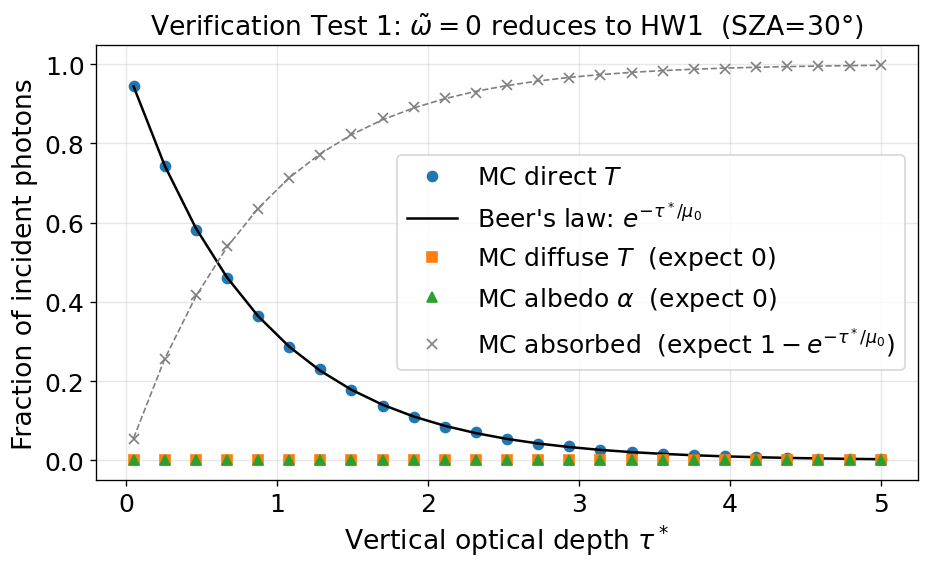

In [9]:
# test $\tilde{\omega} = 0$ should reduce exactly to the HW1 pure-absorption model — direct transmittance $T = e^{-\tau^*/\mu_0}$, albedo $= 0$, no diffuse component.
single_scatter_out = run_monte_carlo_scatter_part1e(tau_star=2.0, sza_deg=30.0, omega=0.0, n_photons=100_000)
print(f"Direct transmittance (omega=0) = {single_scatter_out['T_direct']:.4f}   (Beer: {np.exp(-2.0/np.cos(np.deg2rad(30))):.4f})")

sza_deg  = 30.0
mu0      = np.cos(np.deg2rad(sza_deg))
tau_vals = np.linspace(0.05, 5.0, 25)

T_direct   = np.zeros_like(tau_vals)
T_diffuse  = np.zeros_like(tau_vals)
albedo     = np.zeros_like(tau_vals)
absorpt    = np.zeros_like(tau_vals)

for i, t in enumerate(tau_vals):
    out = run_monte_carlo_scatter_part1e(tau_star=t, sza_deg=sza_deg,
                                         omega=0.0, n_photons=20_000)
    T_direct[i]  = out['T_direct']
    T_diffuse[i] = out['T_diffuse']
    albedo[i]    = out['albedo']
    absorpt[i]   = out['absorptance']

beer = np.exp(-tau_vals / mu0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(tau_vals, T_direct,  'o',  color='C0', label=r'MC direct $T$')
ax.plot(tau_vals, beer,      '-',  color='k',  lw=1.5, label=r"Beer's law: $e^{-\tau^*/\mu_0}$")
ax.plot(tau_vals, T_diffuse, 's',  color='C1', label=r'MC diffuse $T$  (expect 0)')
ax.plot(tau_vals, albedo,    '^',  color='C2', label=r'MC albedo $\alpha$  (expect 0)')
ax.plot(tau_vals, absorpt,   'x',  color='gray', label=r'MC absorbed  (expect $1-e^{-\tau^*/\mu_0}$)')
ax.plot(tau_vals, 1 - beer,  '--', color='gray', lw=1)

ax.set_xlabel(r'Vertical optical depth $\tau^*$')
ax.set_ylabel('Fraction of incident photons')
ax.set_title(rf'Verification Test 1: $\tilde\omega=0$ reduces to HW1  (SZA={int(sza_deg)}°)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
#plt.savefig('figures/verification_omega0.png', bbox_inches='tight')
plt.show()


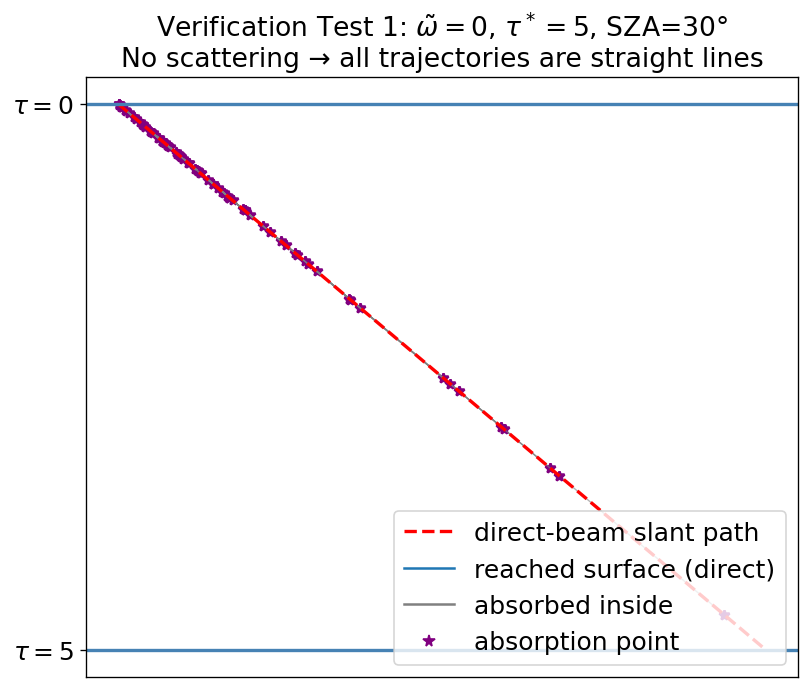

Of 80 traced photons: 0 reached surface, 80 absorbed, 0 diffuse (should be 0), 0 reflected (should be 0)


In [10]:
tau_star = 5.0
sza_deg  = 30.0
n_traces = 80

out = run_monte_carlo_scatter_part1e(tau_star=tau_star, sza_deg=sza_deg,
                                     omega=0.0, n_photons=n_traces,
                                     n_traces=n_traces,
                                     rng=np.random.default_rng(seed=7))

# Direct-beam reference (slant line from TOA to surface)
sin_sza = np.sin(np.deg2rad(sza_deg))
mu0     = np.cos(np.deg2rad(sza_deg))
x_end   = (tau_star / mu0) * sin_sza

fig, ax = plt.subplots(figsize=(7, 6))

for traj in out['trajectories']:
    end_tau = traj[-1, 1]
    if np.isclose(end_tau, tau_star):
        # reached the surface — direct
        ax.plot(traj[:, 0], traj[:, 1], '-', color='C0', lw=0.8, alpha=0.7)
    else:
        # absorbed somewhere inside the atmosphere
        ax.plot(traj[:, 0], traj[:, 1], '-', color='gray', lw=0.8, alpha=0.6)
        ax.plot(traj[-1, 0], traj[-1, 1], '*', color='purple', ms=6, mew=1.5)

# Direct-beam reference and atmosphere boundaries
ax.plot([0, x_end], [0, tau_star], 'r--', lw=2, label='direct-beam slant path')
ax.axhline(0,        color='steelblue', lw=2)
ax.axhline(tau_star, color='steelblue', lw=2)

# Dummy points for legend
ax.plot([], [], '-', color='C0',  lw=1.5, label='reached surface (direct)')
ax.plot([], [], '-', color='gray', lw=1.5, label='absorbed inside')
ax.plot([], [], '*', color='purple',  ms=7, label='absorption point')

ax.invert_yaxis()
ax.set_yticks([0, tau_star])
ax.set_yticklabels([r'$\tau = 0$', rf'$\tau = {tau_star:g}$'])
ax.set_xticks([])
ax.set_title(rf'Verification Test 1: $\tilde\omega = 0$, $\tau^*={tau_star:g}$, SZA={int(sza_deg)}°'
             '\nNo scattering → all trajectories are straight lines')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('figures/test1_omega0_trajectories.png', bbox_inches='tight')
plt.show()

print(f"Of {n_traces} traced photons: "
      f"{out['n_direct']} reached surface, {out['n_absorbed']} absorbed, "
      f"{out['n_diffuse']} diffuse (should be 0), {out['n_reflected']} reflected (should be 0)")



**Test 2:** for a sza at noon more photons should reach the surface than at sunset, so the direct transmittance should be higher for sza=0 than for sza=60, this is just making sure we have the geometry right and that the slant path is correctly calculated as tau*/mu0, when we include scattering

In [11]:
#**Test 2 for a sza at noon more photons should reach the surface than at sunset, so the direct transmittance should be higher for sza=0 than for sza=60.**
tau_star  = 1.0
omega     = 0.5        
n_photons = 50_000

out_noon   = run_monte_carlo_scatter_part1e(tau_star, sza_deg=0.0,  omega=omega, n_photons=n_photons)
out_sunset = run_monte_carlo_scatter_part1e(tau_star, sza_deg=60.0, omega=omega, n_photons=n_photons)

print(f"SZA = 0°   (noon):    T_direct = {out_noon['T_direct']:.4f}")
print(f"SZA = 60°  (low sun): T_direct = {out_sunset['T_direct']:.4f}")
print(f"\nDoes T_direct(0°) > T_direct(60°)?  "
      f"{'PASS' if out_noon['T_direct'] > out_sunset['T_direct'] else 'FAIL'}")

SZA = 0°   (noon):    T_direct = 0.3682
SZA = 60°  (low sun): T_direct = 0.1365

Does T_direct(0°) > T_direct(60°)?  PASS


---
## Part I.3: Questions

**(a)** For $\tilde{\omega}$ increasing from 0 → 1, how do the surface direct transmittance, surface diffuse transmittance, and the albedo change?


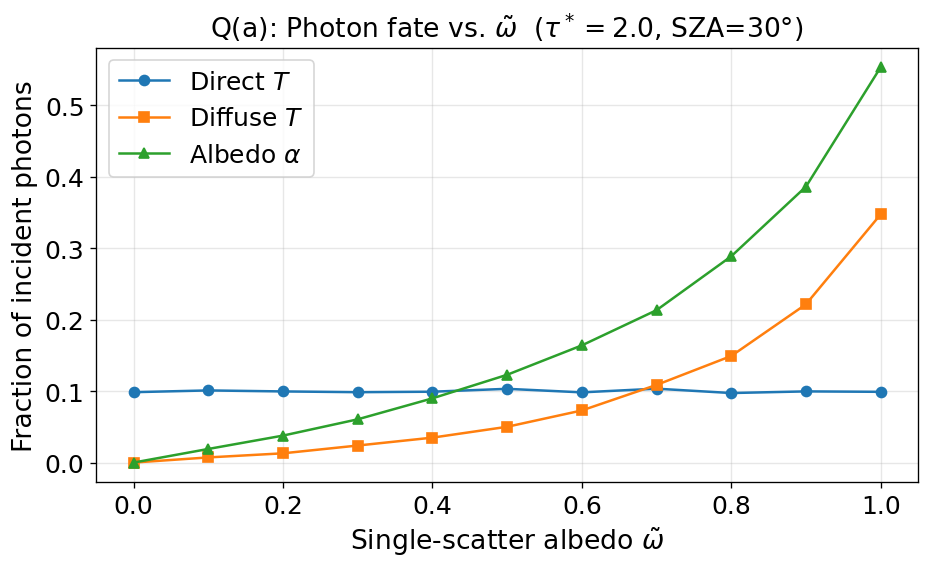

In [12]:
# vary single scatter from 0 to 1 and see how the direct and diffuse transmittance change.


tau_star = 2.0
sza_deg  = 30.0
single_scatter_albedos = np.linspace(0, 1, 11)

T_direct_arr  = []
T_diffuse_arr = []
albedo_arr    = []

for w in single_scatter_albedos:
    out = run_monte_carlo_scatter_part1e(tau_star=tau_star, sza_deg=sza_deg,
                                         omega=w, n_photons=20_000)
    T_direct_arr.append(out['T_direct'])
    T_diffuse_arr.append(out['T_diffuse'])
    albedo_arr.append(out['albedo'])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(single_scatter_albedos, T_direct_arr,  'o-', label=r'Direct $T$')
ax.plot(single_scatter_albedos, T_diffuse_arr, 's-', label=r'Diffuse $T$')
ax.plot(single_scatter_albedos, albedo_arr,    '^-', label=r'Albedo $\alpha$')

ax.set_xlabel(r'Single-scatter albedo $\tilde\omega$')
ax.set_ylabel('Fraction of incident photons')
ax.set_title(rf'Q(a): Photon fate vs. $\tilde\omega$  ($\tau^*={tau_star}$, SZA={int(sza_deg)}°)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/qa_omega_sweep.png', bbox_inches='tight')
plt.show()
                         


## **Answer to Q(b):** ##
As the single-scatter albedo $\tilde{\omega}$ increases from 0 to 1, the direct transmittance $T$ stays the same this is because the direct transmittance only counts photons that reach the surface without ever scattering, so it is unaffected by whether interactions are scattering or absorbing. The diffuse transmittance increases this is because as as the single scatter albedo increase more photons are diffusley scattering. The albedo also increases the most with increaseing ssa this is because albedo is calculated by (flux back to space) / (incident flux) , so more photons are reflected into space 


**(b)** For $\tau \ll 1$, what is the relationship between diffuse radiation at the surface and $\tilde{\omega}$, $\tau$, and $\mu_0$? How does this compare to an approximate analytical solution of the RTE?


## Q(b): Single-scattering approximation in the optically thin limit

Step 1 — Fraction of photons that undergo an extinction event: 
With slant-path optical depth $\tau^*/\mu_0$. Probability it makes it all the way through *without interacting at all* =  $ e^{-\tau^*/\mu_0} $ . Therefore probability it does interact somewhere along the way:


$$f_{\rm ext} = 1 - e^{-\tau^*/\mu_0} \;\approx\; \frac{\tau^*}{\mu_0} \quad (\tau^* \ll 1).$$
- this approximation comes from taylor expanding 1−e^-x

Step 2 — Fraction of those photons that are scattered (not absorbed)
By the very definition of the single-scatter albedo, $$f_{\rm scat \mid ext} = \tilde\omega.$$


Step 3 — Fraction of scattered photons that make it to the surface:
For isotropic scattering, the new direction is uniform. The sphere's lower hemisphere accounts for exactly half of solid angle, so $$ P(surface direction) = 1/2 $$
Given that the remaining atmosphere below the scattering point is very thin, the probability of survival to the surface is ≈ 1

Step 3 —**Combine by Multiplying Fractions/ probability:**
$$\boxed{T_{\rm diffuse} \;=\; \frac{\tau^*}{\mu_0}\cdot\tilde\omega\cdot\frac{1}{2} \;=\; \frac{\tilde\omega\,\tau^*}{2\mu_0}.}$$



| Symbol | Meaning |
|---|---|
| $\tilde\omega$ | Single-scatter albedo |
| $\tau^*$ | Atmospheric optical depth |
| $\mu$ | Cosine of the SZA |

## **Answer** Here  $T_{\rm diffuse}$ scales **linearly** with $\tilde\omega$, **linearly** with $\tau^*$, and **inversely** with $\mu_0$, with a greater response when the sun is at an angle for  $\mu_0$. You can see this in the graph below and in the equation above.

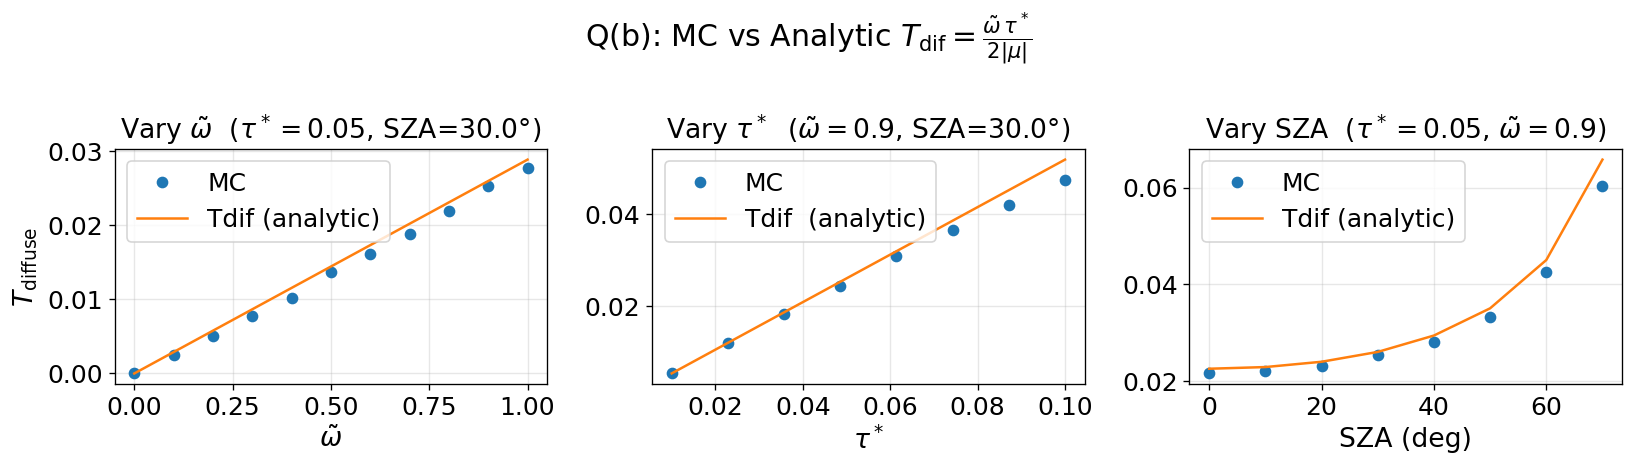

In [13]:
import numpy as np
import matplotlib.pyplot as plt



def Tdif(omega, tau, mu0):
    return omega * tau / (2.0 * mu0)


F0       = 1.0
sza_deg  = 30.0
mu0      = np.cos(np.deg2rad(sza_deg))
tau_thin = 0.05



fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# --- Sweep 1: vary omega ---
omegas = np.linspace(0.0, 1.0, 11)
T_diff_mc = []
for w in omegas:
    out = run_monte_carlo_scatter_part1e(tau_thin, sza_deg, w, n_photons=300_000)
    T_diff_mc.append(out['T_diffuse'])
T_diff_analytic = [Tdif(w, tau_thin, mu0) for w in omegas]

ax = axes[0]
ax.plot(omegas, T_diff_mc,      'o',  label='MC')
ax.plot(omegas, T_diff_analytic, '-', label='Tdif (analytic)')
ax.set_xlabel(r'$\tilde\omega$')
ax.set_ylabel(r'$T_{\rm diffuse}$')
ax.set_title(rf'Vary $\tilde\omega$  ($\tau^*={tau_thin}$, SZA={sza_deg}°)')
ax.legend(); ax.grid(alpha=0.3)

# --- Sweep 2: vary tau* ---
taus  = np.linspace(0.01, 0.1, 8)
omega = 0.9
T_diff_mc = []
for t in taus:
    out = run_monte_carlo_scatter_part1e(t, sza_deg, omega, n_photons=300_000)
    T_diff_mc.append(out['T_diffuse'])
T_diff_analytic = [Tdif(omega, t, mu0) for t in taus]

ax = axes[1]
ax.plot(taus, T_diff_mc,      'o',  label='MC')
ax.plot(taus, T_diff_analytic, '-', label='Tdif  (analytic)')
ax.set_xlabel(r'$\tau^*$')
ax.set_title(rf'Vary $\tau^*$  ($\tilde\omega={omega}$, SZA={sza_deg}°)')
ax.legend(); ax.grid(alpha=0.3)

# --- Sweep 3: vary SZA ---
sza_range = np.linspace(0, 70, 8)
omega     = 0.9
T_diff_mc = []
for sza in sza_range:
    out = run_monte_carlo_scatter_part1e(tau_thin, sza, omega, n_photons=300_000)
    T_diff_mc.append(out['T_diffuse'])
T_diff_analytic = [Tdif(omega, tau_thin, np.cos(np.deg2rad(sza)))
                   for sza in sza_range]

ax = axes[2]
ax.plot(sza_range, T_diff_mc,      'o',  label='MC')
ax.plot(sza_range, T_diff_analytic, '-', label='Tdif (analytic)')
ax.set_xlabel('SZA (deg)')
ax.set_title(rf'Vary SZA  ($\tau^*={tau_thin}$, $\tilde\omega={omega}$)')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle(r'Q(b): MC vs Analytic $T_{\rm dif} = \frac{\tilde\omega\,\tau^*}{2|\mu|}$')
plt.tight_layout()
plt.savefig('figures/qb_single_scatter.png', bbox_inches='tight')
plt.show()


**(c)** Prove that the sky is blue and sunsets are red.


## Q(c) physics: from Mie theory to the Monte Carlo model

The Monte Carlo model does not depend on wavelength but it does takes into account the value of $\tau^*$. The wavelength dependence we need for Q(c) comes from  wavelength dependent extinction coefficient (and thus tau)

$$Q_{\rm ext} = f(\lambda).$$

For the  **Rayleigh regime**:

$$Q_{\rm ext} \;\propto\; \frac{1}{\lambda^4}.$$

Since the scattering optical depth is $\tau_{\rm scat} = N \sigma_{\rm scat} z$ and $\sigma_{\rm scat} = Q_{\rm ext}\,\pi r^2$, the wavelength dependence is inherited directly:

$$\tau(\lambda) \;\propto\; \frac{1}{\lambda^4}.$$



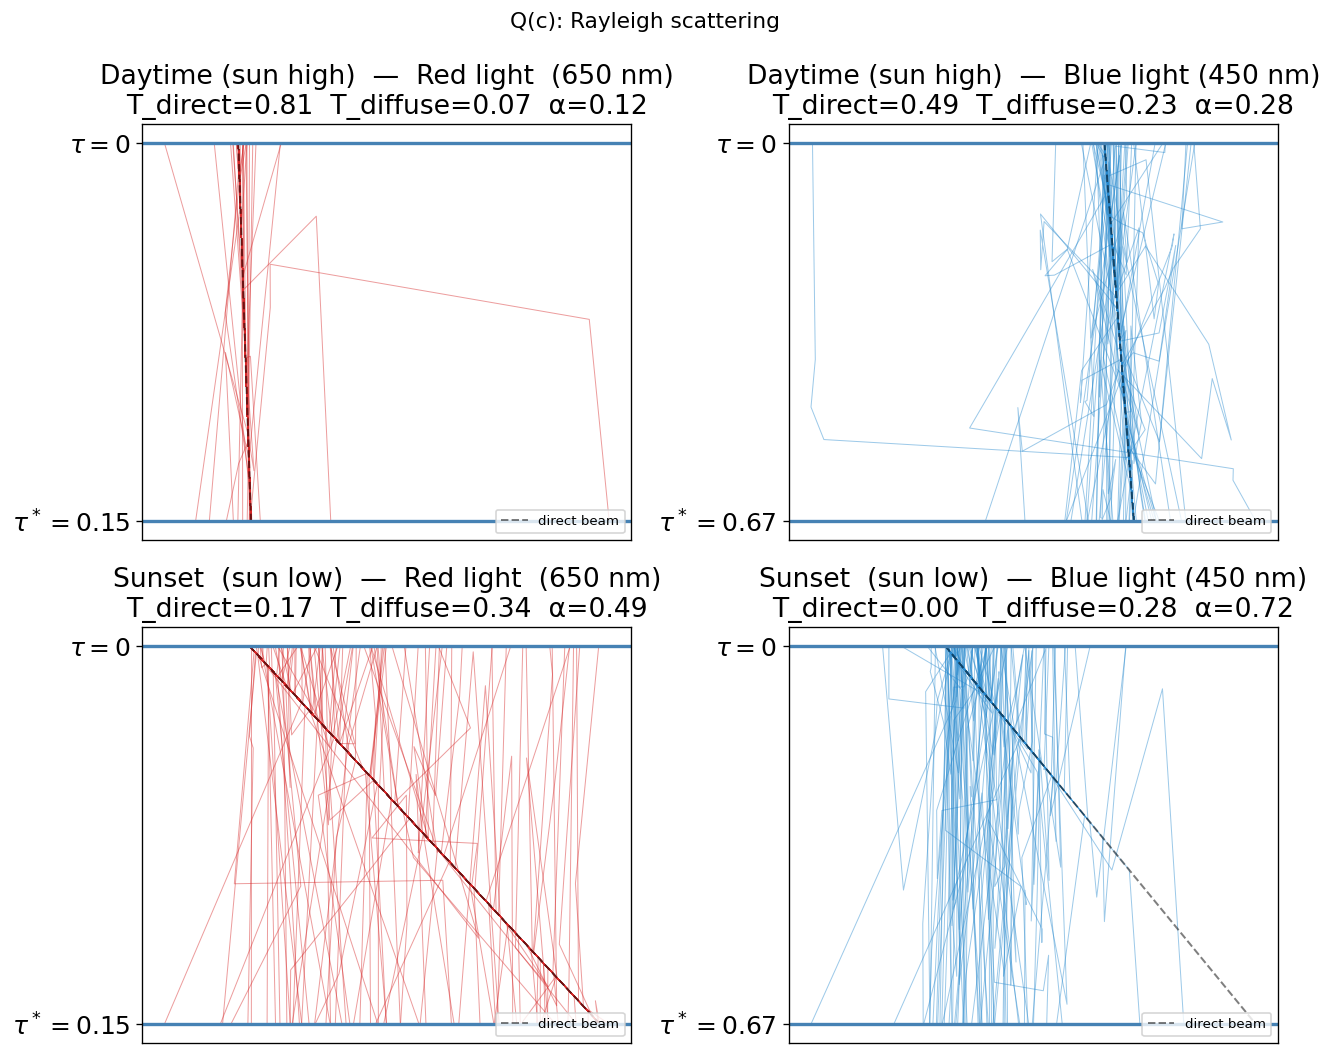

In [14]:
# --- Q(c): Why the sky is blue and sunsets are red ---
# convert wavelength to a tau value before calling the MC function.

def rayleigh_tau(wavelength_nm, tau_ref=0.30, lam_ref=550):
    """Rayleigh optical depth scaled from a reference wavelength. 

    Rayleigh cross-section ~ 1/lambda^4, so tau scales the same way.""" # needs reference tau value at a reference wavelength, and then scales as (lambda_ref / lambda)^4
    return tau_ref * (lam_ref / wavelength_nm)**4

tau_red   = rayleigh_tau(650)   
tau_blue  = rayleigh_tau(450)  

scenarios = [
    ('Daytime (sun high)', 30.0),
    ('Sunset  (sun low)',  85.0),
]
wavelengths = [
    ('Red light  (650 nm)',  tau_red,  '#d62728'),
    ('Blue light (450 nm)',  tau_blue, "#2789ce"),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

for i, (label_sza, sza) in enumerate(scenarios):
    for j, (label_w, tau, color) in enumerate(wavelengths):
        ax  = axes[i, j]
        out = run_monte_carlo_scatter_part1e(tau_star=tau, sza_deg=sza,
                                             omega=1.0, n_photons=200,
                                             n_traces=200,
                                             rng=np.random.default_rng(seed=11))

        sin_sza = np.sin(np.deg2rad(sza))
        mu0     = np.cos(np.deg2rad(sza))
        x_end   = (tau / mu0) * sin_sza

        for traj in out['trajectories']:
            ax.plot(traj[:, 0], traj[:, 1], '-', color=color, lw=0.6, alpha=0.45)

        ax.plot([0, x_end], [0, tau], 'k--', lw=1.2, alpha=0.5, label='direct beam')
        ax.axhline(0,   color='steelblue', lw=2)
        ax.axhline(tau, color='steelblue', lw=2)
        ax.invert_yaxis()
        ax.set_xticks([])
        ax.set_yticks([0, tau])
        ax.set_yticklabels([r'$\tau = 0$', rf'$\tau^* = {tau:.2f}$'])
        ax.set_title(f'{label_sza}  —  {label_w}\n'
                     f"T_direct={out['T_direct']:.2f}  "
                     f"T_diffuse={out['T_diffuse']:.2f}  "
                     f"α={out['albedo']:.2f}")
        ax.legend(loc='lower right', fontsize=8)

fig.suptitle(r'Q(c): Rayleigh scattering',
             fontsize=13)
plt.tight_layout()
plt.savefig('figures/qc_sky_color.png', bbox_inches='tight')
plt.show()

## Q(c) Answer
For the sun directly overhead there is larger diffuse transmittance for blue light than for red light this means that in the atmosphere there is more blue light being scattered. For the sun during sunset there is larger diffuse transmittance for red light than for blue light now in this scenario more red light is scattered in the sky. These are shown in the graphs above, and mainy in the T_diffuse calculation which is done using the MC model and is in the plots titles and is calculated by `n_diffuse / n_photons`  . 


**(d)** Your own question + hypothesis answered with the model.

### Q(d): My own question

Two atmospheres can have the same **direct transmittance** if their slant-path optical depths are equal, we learned this in HW1 using beer's law. For example, a shorter atmosphere at a low sun angle vs. a taller atmosphere with the sun overhead can have the same lant-path optical depth.A real life example of these two conditions is sunset at somewhere with a high atlitude and solar noon at a place at or below sea-level.  But do they also have the same **diffuse transmittance** and **albedo** under an atmosphere that has scattering, and if so which atmosphere has more transmittance? 

In other words, is the surface radiation field fully determined by slant-path optical depth, or does the vertical thickness of the atmosphere matter for scattering? My first guess was that it does not since initally the photon's are traveling the same length it's just a different angle but once a photon can scatter this angle changes, so I do think there would be a difference and that the discrepancy would get larger for larger single scatter alebdos. I think the atmosphere that is taller (sea-level) would have more diffuse transmittance because it has more available space to scatter

Sea-level atmosphere
(Z=17 km, SZA=0°)  Z= 17.0 km  tau*=2.00  slant tau=2.00
High-altitude atmosphere
(Z=8.5 km, SZA=60°)  Z=  8.5 km  tau*=1.00  slant tau=2.00


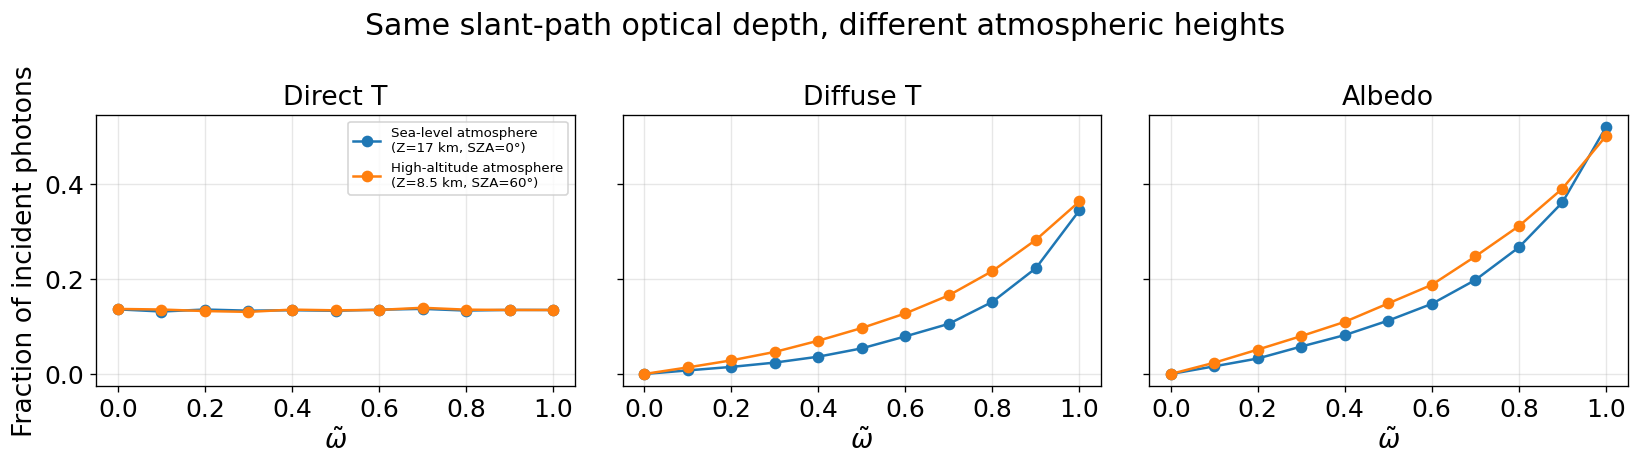

In [15]:
# --- Reframe in terms of physical atmospheric heights ---
# tau* = beta_ext * Z_atm.  If we fix the extinction coefficient,
# changing the atmospheric height changes tau* proportionally.

# Earth's scale height for reference
Z_SCALE = 8500.0          # meters
beta_ext = 1.0 / Z_SCALE  # 1/m  — chosen so tau*=1 when Z = 8500 m

# Two atmospheres with the same SLANT-PATH optical depth but different
# vertical thicknesses.  We choose heights and SZAs such that
#   Z_atm / mu_0 = constant   →   slant tau is constant.
cases = [
    {'Z_atm': 17_000.0, 'sza_deg': 0.0,   # tall atmosphere, sun overhead
     'label': 'Sea-level atmosphere\n(Z=17 km, SZA=0°)'},
    {'Z_atm': 8_500.0,  'sza_deg': 60.0,  # half-thickness, sun at 60°
     'label': 'High-altitude atmosphere\n(Z=8.5 km, SZA=60°)'},
]

# Compute tau* for each case from the physical height
for c in cases:
    c['tau_star'] = beta_ext * c['Z_atm']
    c['slant_tau'] = c['tau_star'] / np.cos(np.deg2rad(c['sza_deg']))
    print(f"{c['label']:<35}  Z={c['Z_atm']/1000:>5.1f} km  "
          f"tau*={c['tau_star']:.2f}  "
          f"slant tau={c['slant_tau']:.2f}")

# --- Sweep over single-scatter albedo ---
omegas = np.linspace(0, 1, 11)
results = {c['label']: {'T_d': [], 'T_diff': [], 'alb': []} for c in cases}

for w in omegas:
    for c in cases:
        out = run_monte_carlo_scatter_part1e(c['tau_star'], c['sza_deg'],
                                             omega=w, n_photons=30_000)
        results[c['label']]['T_d'].append(out['T_direct'])
        results[c['label']]['T_diff'].append(out['T_diffuse'])
        results[c['label']]['alb'].append(out['albedo'])

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, key, title in zip(axes,
                          ['T_d', 'T_diff', 'alb'],
                          ['Direct T', 'Diffuse T', 'Albedo']):
    for c in cases:
        ax.plot(omegas, results[c['label']][key], 'o-', label=c['label'])
    ax.set_xlabel(r'$\tilde\omega$')
    ax.set_title(title)
    ax.grid(alpha=0.3)
axes[0].set_ylabel('Fraction of incident photons')
axes[0].legend(fontsize=8)
fig.suptitle('Same slant-path optical depth, different atmospheric heights')
plt.tight_layout()
plt.savefig('figures/qd_heights_vs_scattering.png', bbox_inches='tight')
plt.show()

**Result:** Direct $T$ is identical between the two cases, as predicted. 

Diffuse $T$ and albedo systematically differ between the two cases (middle and right panels), with the gap is widest at intermediate $\tilde\omega$ where scattering is common but not guaranteed. The shorter atmosphere in orange has greater diffuse transmittance, which I find suprising because I would think the taller atmosphere would allow for more instances for scattering but it also allows more instances for absorbtion. In the taller atmosphere in blue after the first scatter, photons typically need a longer journey to escape, more chances of either scattering or absorbtion and  more end up absorbed and fewer end up as diffuse or albedo. In contrast the shorter atmosphere at a higher altitude from its first scattering location the depth it must traverse to escape is set by the vertical thicknes of the slab. The high-altitude column is half as thick vertically, so scattered photons escape after fewer subsequent interactionsand therefore experience fewer absorption opportunities. At a SSA of 1 the diffuse transmitance and the albedo are the same since here all of the photons scatter and there is no absorption. 

**New Question:**  If there was no absorbtion and just scattering, would the sea level tall atmosphere have more diffuse transmittance? To do so I will comment out absorbtion in the MC model.



Sea-level atmosphere
(Z=17 km, SZA=0°)  Z= 17.0 km  tau*=2.00  slant tau=2.00
High-altitude atmosphere
(Z=8.5 km, SZA=60°)  Z=  8.5 km  tau*=1.00  slant tau=2.00


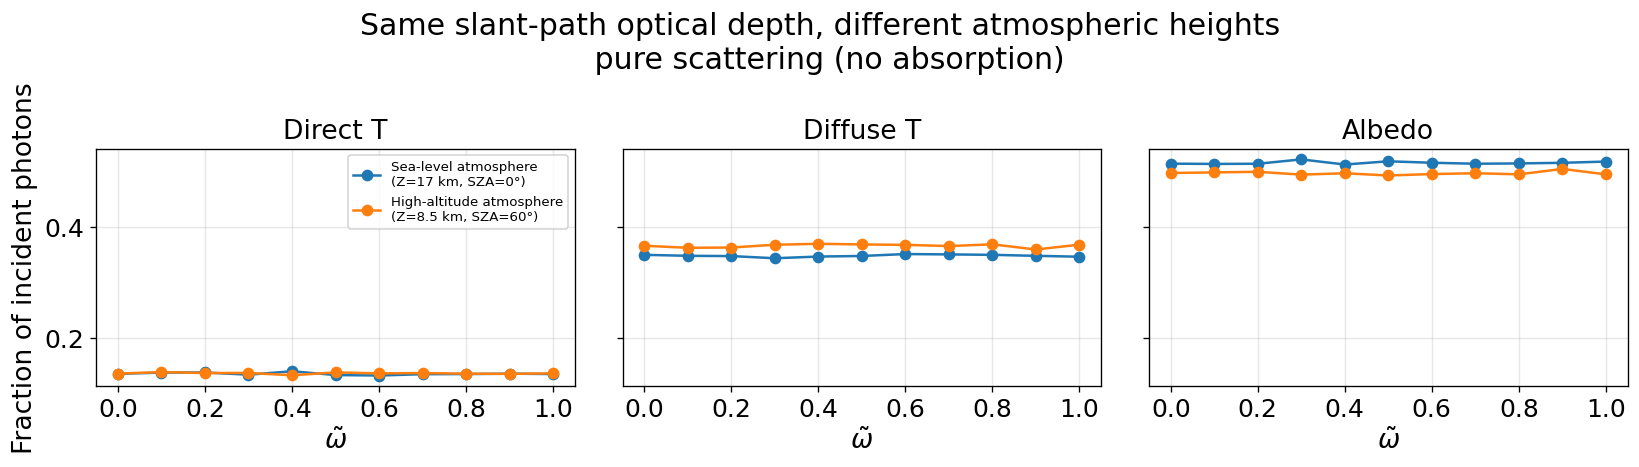

In [16]:

def run_monte_carlo_scatter_no_abs(tau_star, sza_deg, omega,
                                   n_photons=N_PHOTONS, rng=rng,
                                   n_traces=0):
    """HW3 Part I — pure-scattering version (absorption commented out).
    
    Every interaction is treated as a scatter. The `omega` argument is
    accepted for signature compatibility but has no effect.

    Each photon's fate is one of:
      - direct   : reached surface without ever scattering
      - diffuse  : reached surface after scattering at least once
      - reflected: exited top of atmosphere after scattering (contributes to albedo)
      - absorbed : disabled in this version — n_absorbed will always be 0
    """
    mu0 = np.cos(np.deg2rad(sza_deg))
    if mu0 <= 0.0:
        return {'T_direct': 0.0, 'T_diffuse': 0.0, 'albedo': 0.0,
                'absorptance': 1.0, 'tau_star': tau_star,
                'sza_deg': sza_deg, 'omega': omega, 'mu0': mu0,
                'trajectories': []}

    sin_sza = np.sin(np.deg2rad(sza_deg))
    k_init  = np.array([sin_sza, 0.0, -mu0])

    n_direct    = 0
    n_diffuse   = 0
    n_reflected = 0
    n_absorbed  = 0
    trajectories = []

    for i in range(n_photons):
        record_this = (i < n_traces)

        k         = k_init.copy()
        x         = 0.0
        tau_pos   = 0.0
        scattered = False
        traj      = [(x, tau_pos)] if record_this else None

        while True:
            ds = sample_path_length(rng)
            dtau_vert  = -ds * k[2]
            tau_pos_n  = tau_pos + dtau_vert
            dx         =  ds * k[0]
            x_n        = x + dx

            if tau_pos_n >= tau_star:
                if record_this:
                    frac = (tau_star - tau_pos) / dtau_vert
                    traj.append((x + frac * dx, tau_star))
                if scattered:
                    n_diffuse += 1
                else:
                    n_direct += 1
                break
            if tau_pos_n <= 0.0:
                if record_this:
                    frac = (0.0 - tau_pos) / dtau_vert
                    traj.append((x + frac * dx, 0.0))
                n_reflected += 1
                break

            tau_pos = tau_pos_n
            x       = x_n
            if record_this:
                traj.append((x, tau_pos))

            # 5.1.a: scatter or absorb?  --- COMMENTED OUT for pure-scattering ---
            # if rng.uniform(0.0, 1.0) >= omega:
            #     n_absorbed += 1
            #     break

            # Every interaction is now a scatter
            cos_th, phi = sample_scatter_angles_isotropic(rng)
            k = rotate_to_model_frame(k, cos_th, phi)

            scattered = True

        if record_this:
            trajectories.append(np.array(traj))

    return {
        'T_direct':    n_direct    / n_photons,
        'T_diffuse':   n_diffuse   / n_photons,
        'T_total':    (n_direct + n_diffuse) / n_photons,
        'albedo':      n_reflected / n_photons,
        'absorptance': n_absorbed  / n_photons,    # will always be 0.0
        'n_direct':    n_direct,
        'n_diffuse':   n_diffuse,
        'n_reflected': n_reflected,
        'n_absorbed':  n_absorbed,
        'trajectories': trajectories,
        'tau_star': tau_star, 'sza_deg': sza_deg, 'omega': omega, 'mu0': mu0,
    }


# --- Reframe in terms of physical atmospheric heights ---
# tau* = beta_ext * Z_atm.  If we fix the extinction coefficient,
# changing the atmospheric height changes tau* proportionally.

# Earth's scale height for reference
Z_SCALE = 8500.0          # meters
beta_ext = 1.0 / Z_SCALE  # 1/m  — chosen so tau*=1 when Z = 8500 m

# Two atmospheres with the same SLANT-PATH optical depth but different
# vertical thicknesses.  We choose heights and SZAs such that
#   Z_atm / mu_0 = constant   →   slant tau is constant.
cases = [
    {'Z_atm': 17_000.0, 'sza_deg': 0.0,   # tall atmosphere, sun overhead
     'label': 'Sea-level atmosphere\n(Z=17 km, SZA=0°)'},
    {'Z_atm': 8_500.0,  'sza_deg': 60.0,  # half-thickness, sun at 60°
     'label': 'High-altitude atmosphere\n(Z=8.5 km, SZA=60°)'},
]

# Compute tau* for each case from the physical height
for c in cases:
    c['tau_star'] = beta_ext * c['Z_atm']
    c['slant_tau'] = c['tau_star'] / np.cos(np.deg2rad(c['sza_deg']))
    print(f"{c['label']:<35}  Z={c['Z_atm']/1000:>5.1f} km  "
          f"tau*={c['tau_star']:.2f}  "
          f"slant tau={c['slant_tau']:.2f}")

# --- Sweep over single-scatter albedo ---
omegas = np.linspace(0, 1, 11)
results = {c['label']: {'T_d': [], 'T_diff': [], 'alb': []} for c in cases}

for w in omegas:
    for c in cases:
        out = run_monte_carlo_scatter_no_abs(c['tau_star'], c['sza_deg'],
                                             omega=w, n_photons=30_000)
        results[c['label']]['T_d'].append(out['T_direct'])
        results[c['label']]['T_diff'].append(out['T_diffuse'])
        results[c['label']]['alb'].append(out['albedo'])

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, key, title in zip(axes,
                          ['T_d', 'T_diff', 'alb'],
                          ['Direct T', 'Diffuse T', 'Albedo']):
    for c in cases:
        ax.plot(omegas, results[c['label']][key], 'o-', label=c['label'])
    ax.set_xlabel(r'$\tilde\omega$')
    ax.set_title(title)
    ax.grid(alpha=0.3)
axes[0].set_ylabel('Fraction of incident photons')
axes[0].legend(fontsize=8)
fig.suptitle('Same slant-path optical depth, different atmospheric heights \n pure scattering (no absorption)')
plt.tight_layout()
plt.show()

In [17]:
# At fixed (tau, sza), no absorption
out_tall  = run_monte_carlo_scatter_no_abs(tau_star=2.0, sza_deg=0.0,  omega=1.0, n_photons=200_000)
out_short = run_monte_carlo_scatter_no_abs(tau_star=1.0, sza_deg=60.0, omega=1.0, n_photons=200_000)

print(f"{'case':<25} {'T_dir':>8} {'T_diff':>8} {'albedo':>8} {'sum':>8}")
print(f"{'tall (τ=2, SZA=0)':<25}  {out_tall['T_direct']:.4f}  "
      f"{out_tall['T_diffuse']:.4f}  {out_tall['albedo']:.4f}  "
      f"{out_tall['T_direct']+out_tall['T_diffuse']+out_tall['albedo']:.4f}")
print(f"{'short (τ=1, SZA=60)':<25}  {out_short['T_direct']:.4f}  "
      f"{out_short['T_diffuse']:.4f}  {out_short['albedo']:.4f}  "
      f"{out_short['T_direct']+out_short['T_diffuse']+out_short['albedo']:.4f}")

case                         T_dir   T_diff   albedo      sum
tall (τ=2, SZA=0)          0.1354  0.3473  0.5172  1.0000
short (τ=1, SZA=60)        0.1356  0.3662  0.4983  1.0000


**Result:**  This is not what I predicted. The high altitude shorter atmosphere has slightly more diffuse transmittance, and less albedo. Without absorption, the difference is driven by how many times each photon scatters. The tall vertical atmosphere (sea level) gives every photon room to scatter multiple times randomizing its direction. The short atmosphere lets most photons only 1–2 scatters, this could be preserving more of the initial downward bias, but its also supposed to be random so I am still a bit confused. 

---
## AI Usage Statement

**Tool used:** Claude (Anthropic)

**How it was used:** 

Helped scaffold the notebook structure, port the HW1 Monte Carlo function as a starting point, draft the coordinate-rotation helper following the appendix, and also help with the final version of the model part 1e specifically it helped me loop through all the photons and you can see how the structure of the function changes from model 1c to model 1e.

**What I checked independently:**


One part of the HW I checked independently was question b which asks about the single scattering approximation. I created by approximation with help from Amato and the notes and textbook in the class. When the MC model and the approximation matched up, I became more confident in both the model which was made with the help of AI and my understanding of what was going on. 

**Example of something I verified rather than accepting from AI output:**

For my own exploration I compared two different atmosphere's transmittance, when I took out the absorbtion the two atmosphere's values were very close together. To verify this I added up the fraction of photons for diffuse; direct and albedo to make sure the sum equaled 1. 
